# Worksheet 2 - Density estimator

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV,LeaveOneOut
from scipy.spatial.distance import jensenshannon

**Open data**

In [2]:
df_full = pd.read_csv('sdss_cutout.csv')
print(df_full)

                RA        DEC         Z     phot_u     phot_g     phot_r  \
0       130.089951  52.178097  0.097629  19.854843  18.159964  17.345013   
1       130.173909  52.557767  0.067737  19.250399  17.239248  16.517265   
2       130.081237  52.668188  0.063350  18.680342  17.206959  16.697826   
3       130.291706  52.572373  0.065425  19.726742  17.791235  16.906610   
4       130.013537  52.766588  0.123360  19.386818  17.534359  16.450377   
...            ...        ...       ...        ...        ...        ...   
319953  149.580633  47.033396  0.390038  23.223936  19.346468  17.534588   
319954  150.261929  46.827647  0.204686  20.360432  18.511255  17.276648   
319955  149.937963  46.482358  0.102099  19.087252  17.185118  16.237055   
319956  150.023597  46.260926  0.069142  19.072407  17.949339  17.497790   
319957  149.753111  46.454115  0.070916  18.535280  17.313433  16.803703   

           phot_i     phot_z  
0       16.930433  16.620535  
1       16.083832  15.822

**Task 1**

In [3]:
def cut(data, lower_boundary, upper_boundary):
    
    """
    Cuts input file to needed redshift range.

    Parameters
    ----------
    data: input pandas data
    lower_boundary: decimal
    upper_boundary: decimal

    Returns
    -------
    cut pandas dataframe
    """

    df = data.drop(data[(data.Z < lower_boundary) | (data.Z > upper_boundary)].index)
    df['u_r'] = df['phot_u'] - df['phot_r']
    df.loc[df['u_r'] <= 2.3, 'population'] = 'blue'
    df.loc[df['u_r'] > 2.3, 'population'] = 'red'
    
    return df

In [4]:
def angular_map(df):
    
    """
    
    Divides given df into red and blue subsamples and plots angular maps respectively for red, blue and both together.

    Parameters
    ----------
    df: input pandas data that must contain column 'population' with attributes 'red' and 'blue'

    Returns
    -------
    None
        
    """
    

    df_red = df[df['population'] == 'red']
    df_blue = df[df['population'] == 'blue']
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))
    fig.suptitle('Angular map', fontweight="bold", size=14)

    ax1.scatter(df_red['RA'], df_red['DEC'], s=0.5, alpha=0.1, color='red')
    ax2.scatter(df_blue['RA'], df_blue['DEC'], s=0.5, alpha=0.1, color='blue')
    ax3.scatter(df_red['RA'], df_red['DEC'], s=0.5, alpha=0.1, color='red')
    ax3.scatter(df_blue['RA'], df_blue['DEC'], s=0.5, alpha=0.1, color='blue')


    ax1.set_xlabel('RA')
    ax1.set_ylabel('DEC')

    ax2.set_xlabel('RA')
    ax2.set_ylabel('DEC')

    ax3.set_xlabel('RA')
    ax3.set_ylabel('DEC')

    return

In [5]:
# redshift range 0.08-0.12

df = cut(df_full, 0.08, 0.12)
print(df)

                RA        DEC         Z     phot_u     phot_g     phot_r  \
0       130.089951  52.178097  0.097629  19.854843  18.159964  17.345013   
7       130.080073  53.235523  0.118736  19.464210  18.210379  17.555952   
13      130.663027  50.071896  0.095350  20.303741  18.293287  17.320787   
18      131.179422  50.381649  0.117368  19.931213  18.112759  17.150190   
20      131.253821  50.354109  0.118596  19.746584  17.791237  16.751982   
...            ...        ...       ...        ...        ...        ...   
319936  149.619462  46.442470  0.102420  19.849287  18.035412  17.121490   
319941  149.744447  46.309440  0.114387  20.416435  18.376987  17.261572   
319943  149.536604  46.474948  0.102360  18.040950  16.418087  15.617054   
319950  149.777636  47.148649  0.105009  19.260720  17.999435  17.265516   
319955  149.937963  46.482358  0.102099  19.087252  17.185118  16.237055   

           phot_i     phot_z       u_r population  
0       16.930433  16.620535  2.509

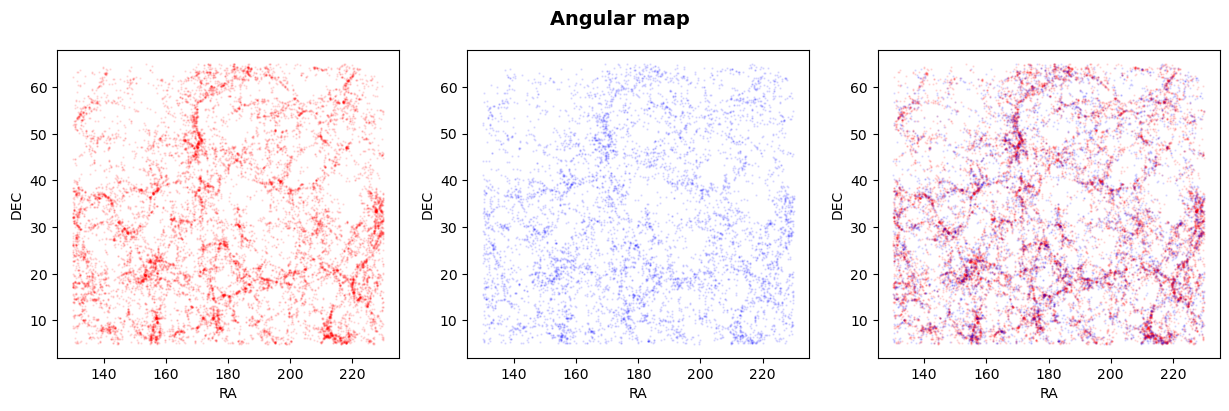

In [6]:
df_zcut = cut(df_full, 0.105, 0.115)
angular_map(df_zcut)

**Task 2**

In [7]:
# data as numpy array in the form of (N, 2), where the two columns are RA and DEC

Xdata = df[['RA', 'DEC']].to_numpy()
print(Xdata)

[[130.08995054  52.17809664]
 [130.08007263  53.23552321]
 [130.66302697  50.0718964 ]
 ...
 [149.53660428  46.47494802]
 [149.77763567  47.1486494 ]
 [149.93796257  46.48235774]]


In [8]:
# Calculate the optimal bandwidth h_opt with sklearn's KernelDensity

bandwidths = np.geomspace(0.05, 2.0, 30)
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                    {'bandwidth':bandwidths}, cv=5)
grid.fit(Xdata) # Xdata has shape (N,2) for 2D
h_opt = grid.best_params_['bandwidth']

In [9]:
print('Optimal bandwidth:', h_opt)

Optimal bandwidth: 2.0


In [10]:
# Compare result to Silverman's rule

N = Xdata.shape[0]

sigma_ra = np.std(Xdata[:, 0])
sigma_dec = np.std(Xdata[:, 1])

sigma = np.sqrt(sigma_ra * sigma_dec)  # geometric mean

h_silverman = 1.06 * sigma * N ** (-1/5)

print('Silverman bandwidth:', h_silverman)

Silverman bandwidth: 2.378709449657939


In [11]:
# different bandwidths:

h_small = h_opt / 3
h_large = h_opt * 3

kde_small = KernelDensity(bandwidth=h_small).fit(Xdata)
kde_opt   = KernelDensity(bandwidth=h_opt).fit(Xdata)
kde_large = KernelDensity(bandwidth=h_large).fit(Xdata)

In [67]:
# evaluation grid:

RA_lin = np.linspace(Xdata[:,0].min(), Xdata[:,0].max(), 100)
DEC_lin = np.linspace(Xdata[:,1].min(), Xdata[:,1].max(), 100)

RA_grid, DEC_grid = np.meshgrid(RA, DEC)

grid_points = np.column_stack([RA_grid.ravel(), DEC_grid.ravel()])

In [13]:
def evaluate_kde(kde):

    """
    
    Evaluats KDE on a grid and returns 2D density map 

    Parameters
    ----------
    kde: fitted KDE model

    Returns
    -------
    density: 2D array
        
    """
    
    log_density = kde.score_samples(grid_points)
    density = np.exp(log_density)  
    return density.reshape(RA_grid.shape)

In [14]:
# Results

density_small = evaluate_kde(kde_small)
density_opt   = evaluate_kde(kde_opt)
density_large = evaluate_kde(kde_large)

In [68]:
RA_data = Xdata[:, 0]
DEC_data = Xdata[:, 1]

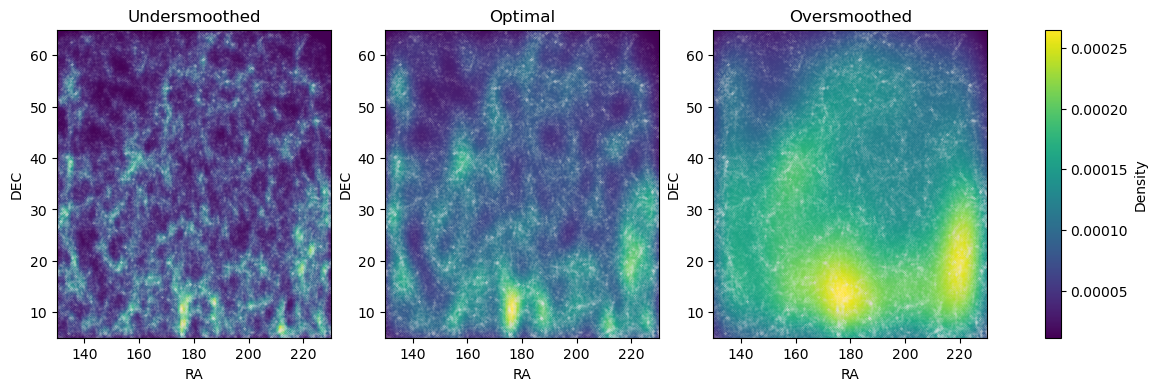

In [75]:
# plot 2D density maps

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, density, title in zip(
    axes,
    [density_small, density_opt, density_large],
    ["Undersmoothed", "Optimal", "Oversmoothed"]
):
    im = ax.imshow(
        density,
        origin='lower',
        extent=[RA.min(), RA.max(), DEC.min(), DEC.max()],
        aspect='auto'
    )
    ax.scatter(RA_data, DEC_data, s=0.05, color='white', alpha=0.1)
    ax.set_title(title)
    ax.set_xlabel("RA")
    ax.set_ylabel("DEC")

fig.colorbar(im, ax=axes, label="Density")
plt.show()


**Task 4**

In [19]:
# calculate optimal KDE at each galaxy position to optain mass-weighted local density

log_rho = kde_opt.score_samples(Xdata) # score_samples returns log-likelihood of each sample
rho = np.exp(log_rho)

In [32]:
# define low and high density samples, by sorting out those in lowest and highest percentile

q25, q75 = np.percentile(rho, [25, 75])

low_density  = df[rho <= q25]
high_density = df[rho >= q75]

print(len(low_density))
print(len(high_density))
print(len(df))

22778
22778
91112


In [33]:
# function for Silverman bandwidth

def silverman_bandwidth(data):

    """
    
    Calculates Silverman's bandwidth

    Parameters
    ----------
    data: numpy array

    Returns
    -------
    bandwidth
        
    """

    sigma = np.std(data)
    N = len(data)
    return 1.06 * sigma * N ** (-1/5)

In [36]:
# KDEs of low and high density for the colour u-r, using Silverman's bandwidth

colour_low_density = low_density['u_r'].to_numpy()
colour_high_density = high_density['u_r'].to_numpy()

h_low_density = silverman_bandwidth(colour_low_density)
h_high_density = silverman_bandwidth(colour_high_density)

kde_low_density  = KernelDensity(bandwidth=h_low_density).fit(colour_low_density[:, None])
kde_high_density = KernelDensity(bandwidth=h_high_density).fit(colour_high_density[:, None])

In [38]:
# Jensen–Shannon(JS) divergence

c_min = min(colour_low_density.min(), colour_high_density.min())
c_max = max(colour_low_density.max(), colour_high_density.max())
cgrid = np.linspace(c_min, c_max, 500)
p_low = np.exp(kde_low_density.score_samples(cgrid[:, np.newaxis]))
p_high = np.exp(kde_high_density.score_samples(cgrid[:, np.newaxis]))
dc = cgrid[1] - cgrid[0]
p_low /= p_low.sum() * dc; p_high /= p_high.sum() * dc
D_JS = jensenshannon(p_low, p_high)**2 # returns sqrt(D_JS), so square it

In [39]:
print("JS divergence:", D_JS)

JS divergence: 0.003970040533256355


In [35]:
# try calculation with smaller bandwidth

log_rho_2 = kde_small.score_samples(Xdata) # score_samples returns log-likelihood of each sample
rho2 = np.exp(log_rho_2)

q_25, q_75 = np.percentile(rho2, [25, 75])

low_density_2  = df[rho <= q_25]
high_density_2 = df[rho >= q_75]

print(len(low_density_2))
print(len(high_density_2))

26662
7624


In [ ]:
colour_low_density_2 = low_density_2['u_r'].to_numpy()
colour_high_density_2 = high_density_2['u_r'].to_numpy()

h_low_density_2 = silverman_bandwidth(colour_low_density_2)
h_high_density_2 = silverman_bandwidth(colour_high_density_2)

kde_low_density_2  = KernelDensity(bandwidth=h_low_density_2).fit(colour_low_density_2[:, None])
kde_high_density_2 = KernelDensity(bandwidth=h_high_density_2).fit(colour_high_density_2[:, None])

In [41]:
# Jensen–Shannon(JS) divergence

c_min_2 = min(colour_low_density_2.min(), colour_high_density_2.min())
c_max_2 = max(colour_low_density_2.max(), colour_high_density_2.max())
cgrid_2 = np.linspace(c_min_2, c_max_2, 500)
p_low_2 = np.exp(kde_low_density_2.score_samples(cgrid_2[:, np.newaxis]))
p_high_2 = np.exp(kde_high_density_2.score_samples(cgrid_2[:, np.newaxis]))
dc_2 = cgrid_2[1] - cgrid_2[0]
p_low_2 /= p_low_2.sum() * dc_2; p_high_2 /= p_high_2.sum() * dc_2
D_JS_2 = jensenshannon(p_low_2, p_high_2)**2 # returns sqrt(D_JS), so square it

In [42]:
print("JS divergence:", D_JS_2)

JS divergence: 0.0033528096163349375


**Task 5**

In [45]:
colours = df['u_r'].to_numpy()

red  = rho[colours > 2.3]
blue = rho[colours <= 2.3]

log_red  = np.log10(red)
log_blue = np.log10(blue)

h_red  = silverman_bandwidth(log_red)
h_blue = silverman_bandwidth(log_blue)

kde_red  = KernelDensity(bandwidth=h_red).fit(log_red[:, None])
kde_blue = KernelDensity(bandwidth=h_blue).fit(log_blue[:, None])

In [46]:
rgrid = np.linspace(min(log_red.min(), log_blue.min()),
                    max(log_red.max(), log_blue.max()), 500)

p_red  = np.exp(kde_red.score_samples(rgrid[:, None]))
p_blue = np.exp(kde_blue.score_samples(rgrid[:, None]))

dr = rgrid[1] - rgrid[0]

p_red  /= p_red.sum() * dr
p_blue /= p_blue.sum() * dr

In [47]:
D_JS_redblue = jensenshannon(p_red, p_blue)**2
print("JS divergence (color → environment):", D_JS_redblue)

JS divergence (color → environment): 0.0014078370923791314


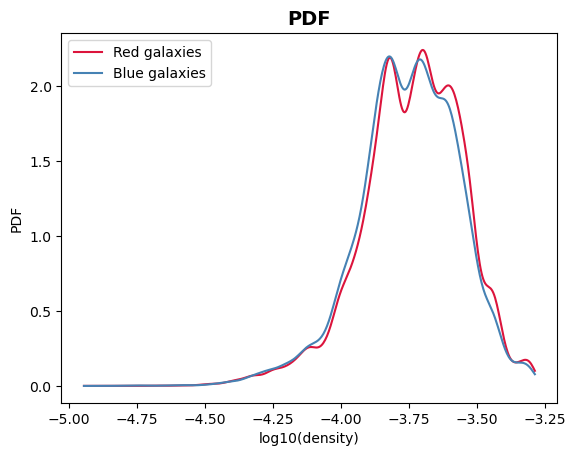

In [59]:
plt.plot(rgrid, p_red, label="Red galaxies", color='crimson')
plt.plot(rgrid, p_blue, label="Blue galaxies", color='steelblue')
plt.xlabel("log10(density)")
plt.ylabel("PDF")
plt.legend()
plt.title('PDF', fontweight="bold", size=14)
plt.show()